# 8장. 텍스트 빈도 분석 (2)한글단어분석

## 4. 데이터 준비

In [1]:
#pip install konlpy 해줘야함
! pip install konlpy


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json
import re
from konlpy.tag import Okt
from collections import Counter
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
from wordcloud import WordCloud

In [3]:
# path = '../data/8장_data/'
path = '/Users/user/Desktop/VSCode/1205_08통계분석/8장_data/'

In [4]:
inputFileName = path+'아시안컵_naver_news'
data = json.loads(open(inputFileName+'.json', 'r', encoding = 'utf-8').read())

data #출력하여 내용 확인

[{'cnt': 1,
  'description': '<b>아시안컵</b> 조별 및 토너먼트 경기 분석 ▲ 페널티킥 성공시킨 손흥민 손흥민이 25일(현지시간) 카타르 알와크라 알자누브 스타디움 열린 2023 아시아축구연맹(AFC) <b>아시안컵</b> 조별리그 E조 최종전 한국과 말레이시아의... ',
  'link': 'https://www.ohmynews.com/NWS_Web/View/at_pg.aspx?CNTN_CD=A0002999660&CMPT_CD=P0010&utm_source=naver&utm_medium=newsearch&utm_campaign=naver_news',
  'org_link': 'https://www.ohmynews.com/NWS_Web/View/at_pg.aspx?CNTN_CD=A0002999660&CMPT_CD=P0010&utm_source=naver&utm_medium=newsearch&utm_campaign=naver_news',
  'pDate': '2024-02-04 11:41:00',
  'title': "전세계 놀라게 한 '코리안타임'... 핵심은 중꺾마였다"},
 {'cnt': 2,
  'description': '일본은 3일 오후 8시 30분(한국시간) 카타르 알라이얀에 위치한 에듀케이션 시티 스타디움에서 열린 2023 아시아축구연맹(AFC) 카타르 <b>아시안컵</b> 8강전에서 이란에 1-2로 패배했다. 이날 경기 패배로 일본의 <b>아시안컵</b> 여정은... ',
  'link': 'https://www.fourfourtwo.co.kr/news/articleView.html?idxno=48179',
  'org_link': 'https://www.fourfourtwo.co.kr/news/articleView.html?idxno=48179',
  'pDate': '2024-02-04 11:41:00',
  'title': "'SNS 테러'는 만국 공통인가...日 축구팬, '극장 PK' 내준 DF 향해 악플 세례

In [5]:
description = ''
for item in data:
    if 'description' in item.keys():
        #특수문자 제거 후 공백을 간격으로 이어붙임
        description = description + re.sub(r'[^\w]', ' ', item['description']) +''
        
description #출력하여 내용 확인

' b 아시안컵  b  조별 및 토너먼트 경기 분석   페널티킥 성공시킨 손흥민 손흥민이 25일 현지시간  카타르 알와크라 알자누브 스타디움 열린 2023 아시아축구연맹 AFC   b 아시안컵  b  조별리그 E조 최종전 한국과 말레이시아의    일본은 3일 오후 8시 30분 한국시간  카타르 알라이얀에 위치한 에듀케이션 시티 스타디움에서 열린 2023 아시아축구연맹 AFC  카타르  b 아시안컵  b  8강전에서 이란에 1 2로 패배했다  이날 경기 패배로 일본의  b 아시안컵  b  여정은    2023 카타르  b 아시안컵  b  4강에서 한국과 맞붙을 요르단이 벌써부터 축제 분위기다  요르단 통신사  페트라 는 3일 한국시간  요르단 대표팀이  b 아시안컵  b  4강 진출을 달성해 이미 100만 달러 약 13억 원  포상금을 확보했다고    모리야스 하지메 감독이 이끄는 일본 대표팀은 3일 한국시각  카타르 알라이얀의 에듀케이션 시티 스타디움에서 열린 이란과의 카타르 b 아시안컵  b  8강전에서 1대2로 충격 역전패했다  먼저 앞서 나간 팀은 일본이었다  전반    일본 축구대표팀이 카타르  b 아시안컵  b  8강에서 이란에 패하면서 4강 진출에 실패한 가운데  일본 대표팀 에이스 쿠보 다케후사가 동갑내기 절친 이강인에게 건넨 말이 눈길을 끈다 쿠보는 이란전을 마친 후 믹스트존에서    앞서 이란과 일본은 지난 3일 오후 8시 30분 카타르 알 라이얀의 에듀케이션 스타디움에서  2023 아시아축구연맹 AFC  카타르  b 아시안컵  b  8강에서 만났다  두 팀 역시 이번  b 아시안컵  b 에서 강력한 우승 후보로 꼽혔다      디펜딩 챔피언  카타르가 우즈베키스탄을 꺾고 4강행을 확정함에 따라 2023 카타르  b 아시안컵  b 의 준결승     b 아시안컵  b  준결승에 진출한 건 이번이 처음이다  8강전에선 이번 대회 돌풍의 주역이었던 타지키스탄과 다퉜는데    지난 3일 카타르 알와크라의 알자누브 스타디움에서 열린  2023 아시아축구

In [6]:
#Okt함수를 사용하기 위해서는 jvm이 필요함
#jvm 깔려있지 않으면 java 설치 및 환경변수 설정 필요

# Okt : KoNLPy에서 제공하는 형태소 분석 라이브러리 함수
# nlp.nouns() 문장에서 명사만 추출해 리스트로 반환
nlp = Okt()
description_N = nlp.nouns(description)
description_N #출력하여 내용 확인

['아시안컵',
 '별',
 '및',
 '토너먼트',
 '경기',
 '분석',
 '페널티킥',
 '성공',
 '손흥민',
 '손흥민',
 '현지',
 '시간',
 '카타르',
 '알와크라',
 '알자누브',
 '스타디움',
 '아시아',
 '축구',
 '연맹',
 '아시안컵',
 '리그',
 '조',
 '최종',
 '전',
 '한국',
 '말레이시아',
 '일본',
 '오후',
 '한국',
 '시간',
 '카타르',
 '알라',
 '얀',
 '위치',
 '에듀',
 '케이',
 '션',
 '시티',
 '스타디움',
 '아시아',
 '축구',
 '연맹',
 '카타르',
 '아시안컵',
 '강전',
 '이란',
 '로',
 '날',
 '경기',
 '패배',
 '일본',
 '아시안컵',
 '여정',
 '카타르',
 '아시안컵',
 '강',
 '한국',
 '요르단',
 '벌써',
 '축제',
 '분위기',
 '요르단',
 '통신사',
 '페트라',
 '한국',
 '시간',
 '요르단',
 '대표팀',
 '아시안컵',
 '강',
 '진출',
 '달성',
 '달러',
 '약',
 '원',
 '포',
 '상금',
 '확보',
 '모리',
 '야스',
 '메',
 '감독',
 '일본',
 '대표팀',
 '한국',
 '시각',
 '카타르',
 '알라',
 '얀',
 '에듀',
 '케이',
 '션',
 '시티',
 '스타디움',
 '이란',
 '카타르',
 '아시안컵',
 '강전',
 '로',
 '충격',
 '역전패',
 '먼저',
 '앞서',
 '팀',
 '일본',
 '전반',
 '일본',
 '축구',
 '대표팀',
 '카타르',
 '아시안컵',
 '강',
 '이란',
 '패',
 '강',
 '진출',
 '가운데',
 '일본',
 '대표팀',
 '에이스',
 '쿠보',
 '다케후사',
 '동갑',
 '내기',
 '절친',
 '이강인',
 '말',
 '눈길',
 '쿠보',
 '이란',
 '전',
 '후',
 '믹스트존',
 '앞서',
 '이란',
 '일본',
 '지난',
 '오

##  5. 데이터 탐색 및 분석 모델 구축

In [7]:
# 각 단어가 나온 횟수 세기
count = Counter(description_N)
count #출력하여 내용 확인

Counter({'카타르': 1446,
         '아시안컵': 1300,
         '일본': 1242,
         '이란': 1161,
         '축구': 906,
         '강전': 815,
         '연맹': 753,
         '아시아': 751,
         '시간': 749,
         '스타디움': 742,
         '에듀': 675,
         '케이': 675,
         '션': 675,
         '얀': 666,
         '시티': 658,
         '경기': 617,
         '알라': 599,
         '현지': 476,
         '강': 415,
         '한국': 389,
         '로': 266,
         '진출': 170,
         '오후': 154,
         '감독': 147,
         '우승': 134,
         '후반': 123,
         '역전패': 120,
         '기자': 115,
         '알': 111,
         '탈락': 111,
         '뉴스': 110,
         '대표팀': 107,
         '전반': 101,
         '야스': 98,
         '선수': 97,
         '김성진': 97,
         '모리': 96,
         '호주': 90,
         '히데': 86,
         '이하': 86,
         '뒤': 84,
         '메': 76,
         '마사': 76,
         '패': 74,
         '후보': 70,
         '리타': 69,
         '추가': 67,
         '대회': 65,
         '라이': 64,
         '자': 62,
         '바크'

In [8]:
# 단어 2글자 이상인 것만 추출해서 탑 100 딕셔너리 형태로 저장
word_count = dict()

for tag, counts in count.most_common(100):
    if(len(str(tag))>1):
        word_count[tag] = counts
        print("%s : %d" % (tag, counts))

카타르 : 1446
아시안컵 : 1300
일본 : 1242
이란 : 1161
축구 : 906
강전 : 815
연맹 : 753
아시아 : 751
시간 : 749
스타디움 : 742
에듀 : 675
케이 : 675
시티 : 658
경기 : 617
알라 : 599
현지 : 476
한국 : 389
진출 : 170
오후 : 154
감독 : 147
우승 : 134
후반 : 123
역전패 : 120
기자 : 115
탈락 : 111
뉴스 : 110
대표팀 : 107
전반 : 101
야스 : 98
선수 : 97
김성진 : 97
모리 : 96
호주 : 90
히데 : 86
이하 : 86
마사 : 76
후보 : 70
리타 : 69
추가 : 67
대회 : 65
라이 : 64
바크 : 62
헤비 : 59
역전승 : 58
클린스만 : 58
선제골 : 56
요르단 : 55
승리 : 55
손흥민 : 54
페널티킥 : 53
동점골 : 52
미토 : 52
이번 : 51
우즈베키스탄 : 51
준결승 : 44
시가 : 44
시각 : 43
선수단 : 43
대한민국 : 39
지난 : 38
시도 : 38
대결 : 37
역전 : 37
국가대표팀 : 36
랭킹 : 36
중동 : 35
위르겐 : 34
위치 : 33
승부차기 : 33
결승 : 31
쿠라 : 29
선취골 : 29
리그 : 28
연장 : 28
토트넘 : 27
도하 : 27
환호 : 27
구보 : 27


In [ ]:
#폰트 설정
#윈도우 시스템 기본 폰트 -> malgun
font_path = "c:/Windows/fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname = font_path).get_name()
matplotlib.rc('font', family = font_name)

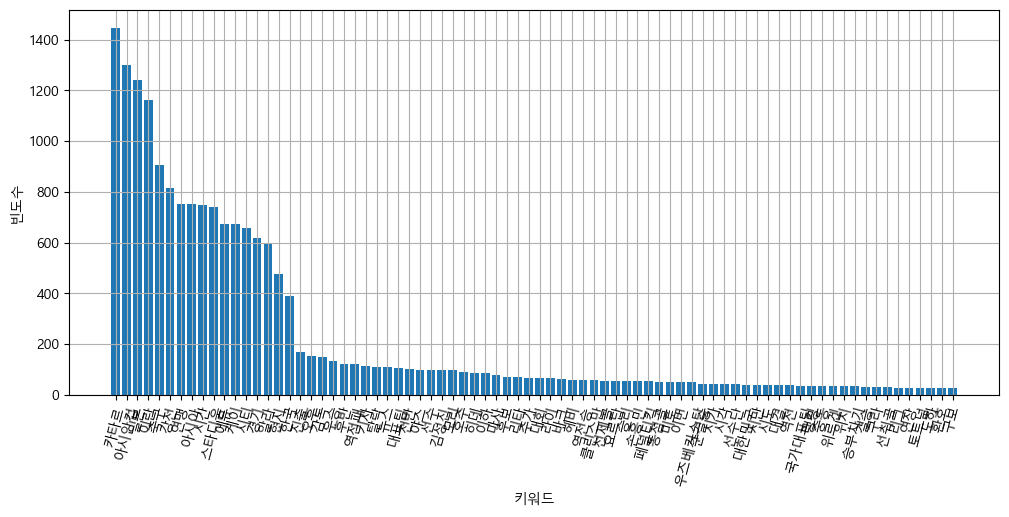

In [10]:
plt.figure(figsize = (12, 5))
plt.xlabel('키워드')
plt.ylabel('빈도수')
plt.grid(True)
sorted_Keys = sorted(word_count, key = word_count.get, reverse = True)
sorted_Values = sorted(word_count.values(), reverse = True)
plt.bar(range(len(word_count)), sorted_Values, align = 'center')
plt.xticks(range(len(word_count)), list(sorted_Keys), rotation = 75)
plt.show()

## 6. 결과 시각화

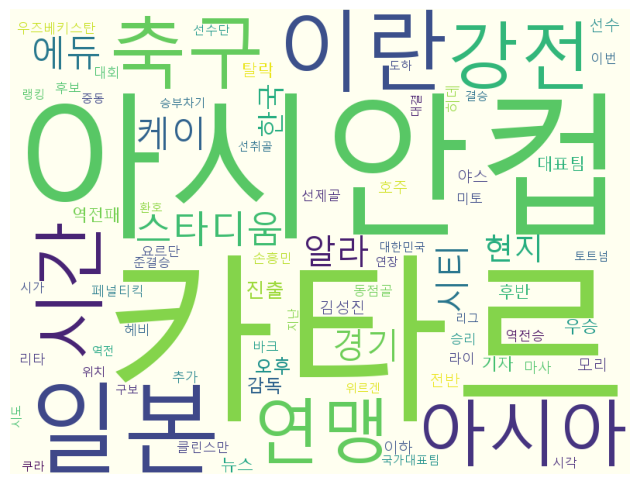

In [11]:
wc = WordCloud( font_path, background_color = 'ivory', width = 800, height = 600)
cloud = wc.generate_from_frequencies(word_count)
plt.figure(figsize = (8, 8))
plt.imshow(cloud)
plt.axis('off')
plt.show()

In [13]:
cloud.to_file(inputFileName + '_cloud.jpg')